In [15]:
"""
"ext" (7-dim, qS/phiS-extended) counterpart of paris3_sc.py.

Same source, LogLike, and S6 semi-coherent scoring as paris3_lhs_s6_ext.py
(which precomputed the LHS seed at /scratch/e1498138/paper/ext/paris3_lhs_s6/lhs_s6.pkl).
Runs a ParisMC search over the 7-dim (logm1, logm2, a, p0, e0, qS, phiS) box,
using that LHS grid (and its ellipsoid prior bounds) as the external seed.
"""
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
sys.path.insert(0, "/nfs/home/svu/e1498138/parismc_dev")

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12 / 12
N_SEGS = 6
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# # Source (matches paper/ext/stage1_anneal.ipynb / paris3_lhs_s6_ext.py)
# m1, m2, a, p0, e0, xI0 = 1e6, 1e1, 0.7, 9.0, 0.4, 1.0
# dist, qS, phiS, qK, phiK = 4.5, np.pi, 0., 0., 0.
# Phi_phi0, Phi_theta0, Phi_r0 = 0.4, 0.0, 0.5

# Source (Mojito light EMRI_G, matches paris2_sc_ext.py)

m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    h_stack, idx_ok = [], []
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            h_stack.append(h_temp)
            idx_ok.append(i)
        except Exception:
            pass
    if h_stack:
        h_batch = gwf.xp.stack(h_stack, axis=0)  # (b, n_chan, N)
        snr = gwf.SNR_semicoherent_batch(loglike_obj.signal, h_batch, N_seg=N_SEGS, phase_max=True)
        for k, i in enumerate(idx_ok):
            out[i] = float(snr[k])
    return out


# ── Load the LHS grid + ellipsoid prior bounds from paris3_lhs_s6_ext.py ──────

lhs_path = f'/scratch/e1498138/paper/ext/emri_g/paris3_lhs_s6_dev/lhs_s6.pkl'
print(f'Loading LHS grid from {lhs_path}...')
with open(lhs_path, 'rb') as f:
    lhs_data = pickle.load(f)

ellipse_lo = lhs_data['ellipse_lo']
ellipse_hi = lhs_data['ellipse_hi']
print('Prior bounds (from paris3_lhs_s6_ext ellipsoid box):')
param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'cosqS', 'phiS']
for name, lo, hi in zip(param_names, ellipse_lo, ellipse_hi):
    print(f'  {name}: [{lo:.5f}, {hi:.5f}]')


def prior_transform(u):
    return ellipse_lo + (ellipse_hi - ellipse_lo) * u


def inverse_prior_transform(params):
    return (np.asarray(params) - ellipse_lo) / (ellipse_hi - ellipse_lo)


Using dt=5s, T=1.0yr, TDI gen=1, N_segs=6
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
Loading LHS grid from /scratch/e1498138/paper/ext/emri_g/paris3_lhs_s6_dev/lhs_s6.pkl...
Prior bounds (from paris3_lhs_s6_ext ellipsoid box):
  logm1: [5.82442, 5.84531]
  logm2: [1.99181, 1.99656]
  a: [0.49134, 0.55132]
  p0: [15.37450, 15.76176]
  e0: [0.74195, 0.74441]
  cosqS: [0.72035, 0.84668]
  phiS: [3.20755, 3.63934]


In [16]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage1_merge_s12_dev_alt/'


In [20]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


AttributeError: 'Sampler' object has no attribute 'prior_transform'

In [ ]:
sampler.now_covariances

[array([[ 1.18332235e-03,  5.93083053e-04,  1.20037003e-03,
         -1.12097275e-03,  3.16944007e-04,  1.82882354e-04,
         -1.07297136e-03],
        [ 5.93083053e-04,  8.64994889e-04,  6.08819890e-04,
         -4.41288098e-04,  5.48780664e-04, -5.05669509e-04,
         -2.45143123e-04],
        [ 1.20037003e-03,  6.08819890e-04,  1.22115689e-03,
         -1.13996881e-03,  2.95394012e-04,  1.89357321e-04,
         -1.10837325e-03],
        [-1.12097275e-03, -4.41288098e-04, -1.13996881e-03,
          1.09787176e-03, -1.34005275e-04, -2.99505557e-04,
          1.10500839e-03],
        [ 3.16944007e-04,  5.48780664e-04,  2.95394012e-04,
         -1.34005275e-04,  1.08217497e-03, -3.06737696e-04,
          9.52153996e-05],
        [ 1.82882354e-04, -5.05669509e-04,  1.89357321e-04,
         -2.99505557e-04, -3.06737696e-04,  1.29910699e-03,
         -1.02666499e-03],
        [-1.07297136e-03, -2.45143123e-04, -1.10837325e-03,
          1.10500839e-03,  9.52153996e-05, -1.02666499e-03

In [ ]:
len(sampler.now_covariances)

9

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.83163782,  1.99392912,  0.51235394, 15.63337143,  0.74358822,
         0.76962931,  3.59178315]])

In [ ]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[ 5.83514779,  1.99396073,  0.52244259, 15.55197899,  0.74279691,
         0.7388605 ,  3.26722709]])

In [ ]:
maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
maxld_pt3

array([[ 5.8402729 ,  1.99556831,  0.53616459, 15.47355337,  0.74262805,
         0.69511254,  3.59395565]])

In [ ]:
log_density(maxld_pt1)

array([96.32509434])

In [12]:
log_density(maxld_pt2)

array([42.76701496])

In [13]:
log_density(maxld_pt3)

array([41.10218335])

In [14]:
log_density(maxld_pt4)

array([41.31356314])

In [15]:
log_density([param_true])

array([100.60446665])

In [16]:
param_ranges = [(5.82442, 5.84531),
                (  1.99181, 1.99656),
                (0.49134, 0.55132),
                (15.37450, 15.76176),
                (0.74195, 0.74441),
                (0.72035, 0.84668),
                (3.20755, 3.63934)
                ]
param_ranges



[(5.82442, 5.84531),
 (1.99181, 1.99656),
 (0.49134, 0.55132),
 (15.3745, 15.76176),
 (0.74195, 0.74441),
 (0.72035, 0.84668),
 (3.20755, 3.63934)]

In [17]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 0.8306067129371271,
 3.5808]

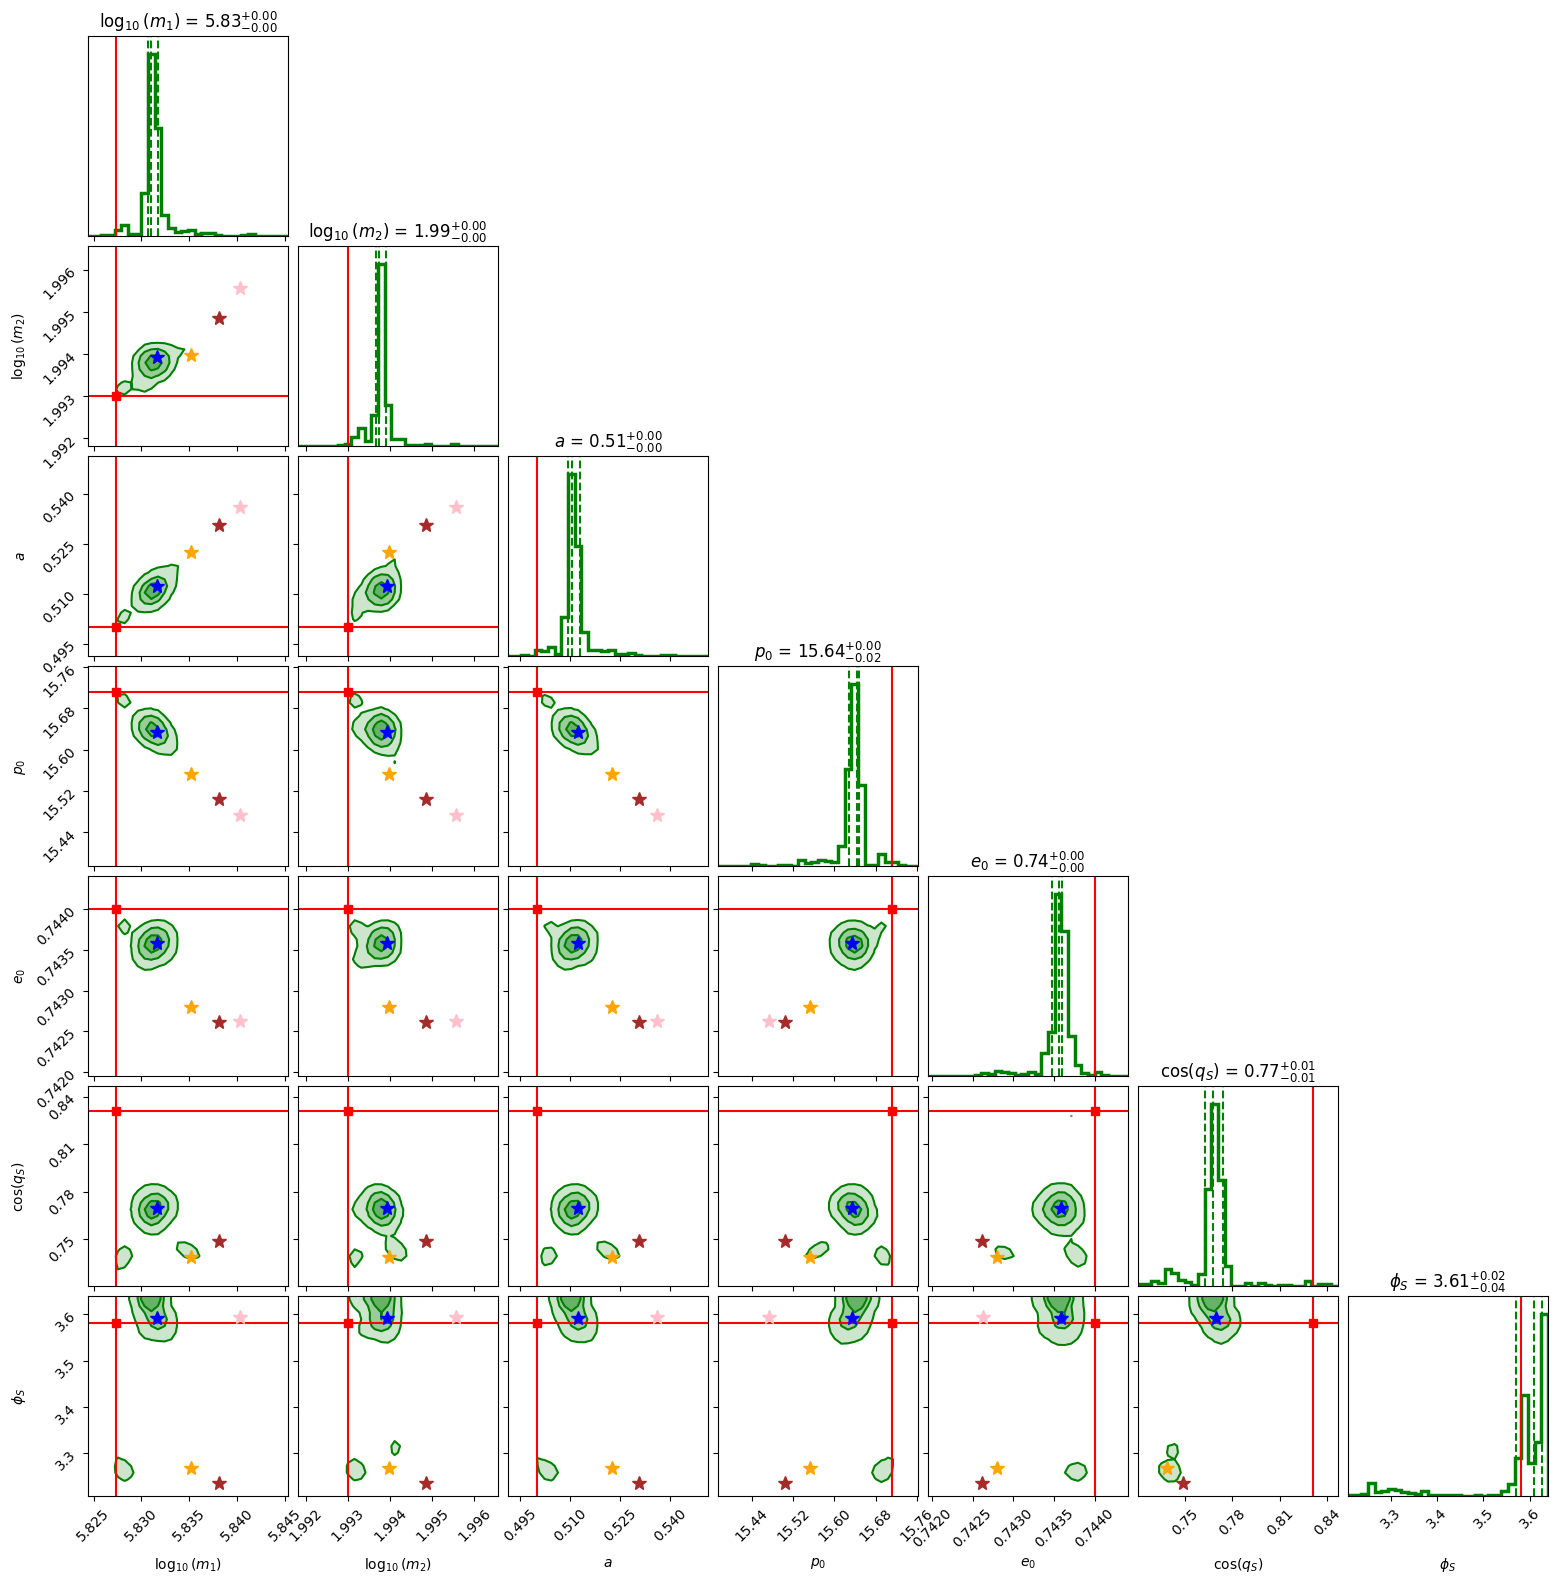

In [18]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt2.reshape(1, -1), 
                       color='orange', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt3.reshape(1, -1), 
                       color='pink', marker='*', ms=10, 
                       reverse=False)
corner.overplot_points(fig, maxld_pt4.reshape(1, -1), 
                       color='brown', marker='*', ms=10, 
                       reverse=False)


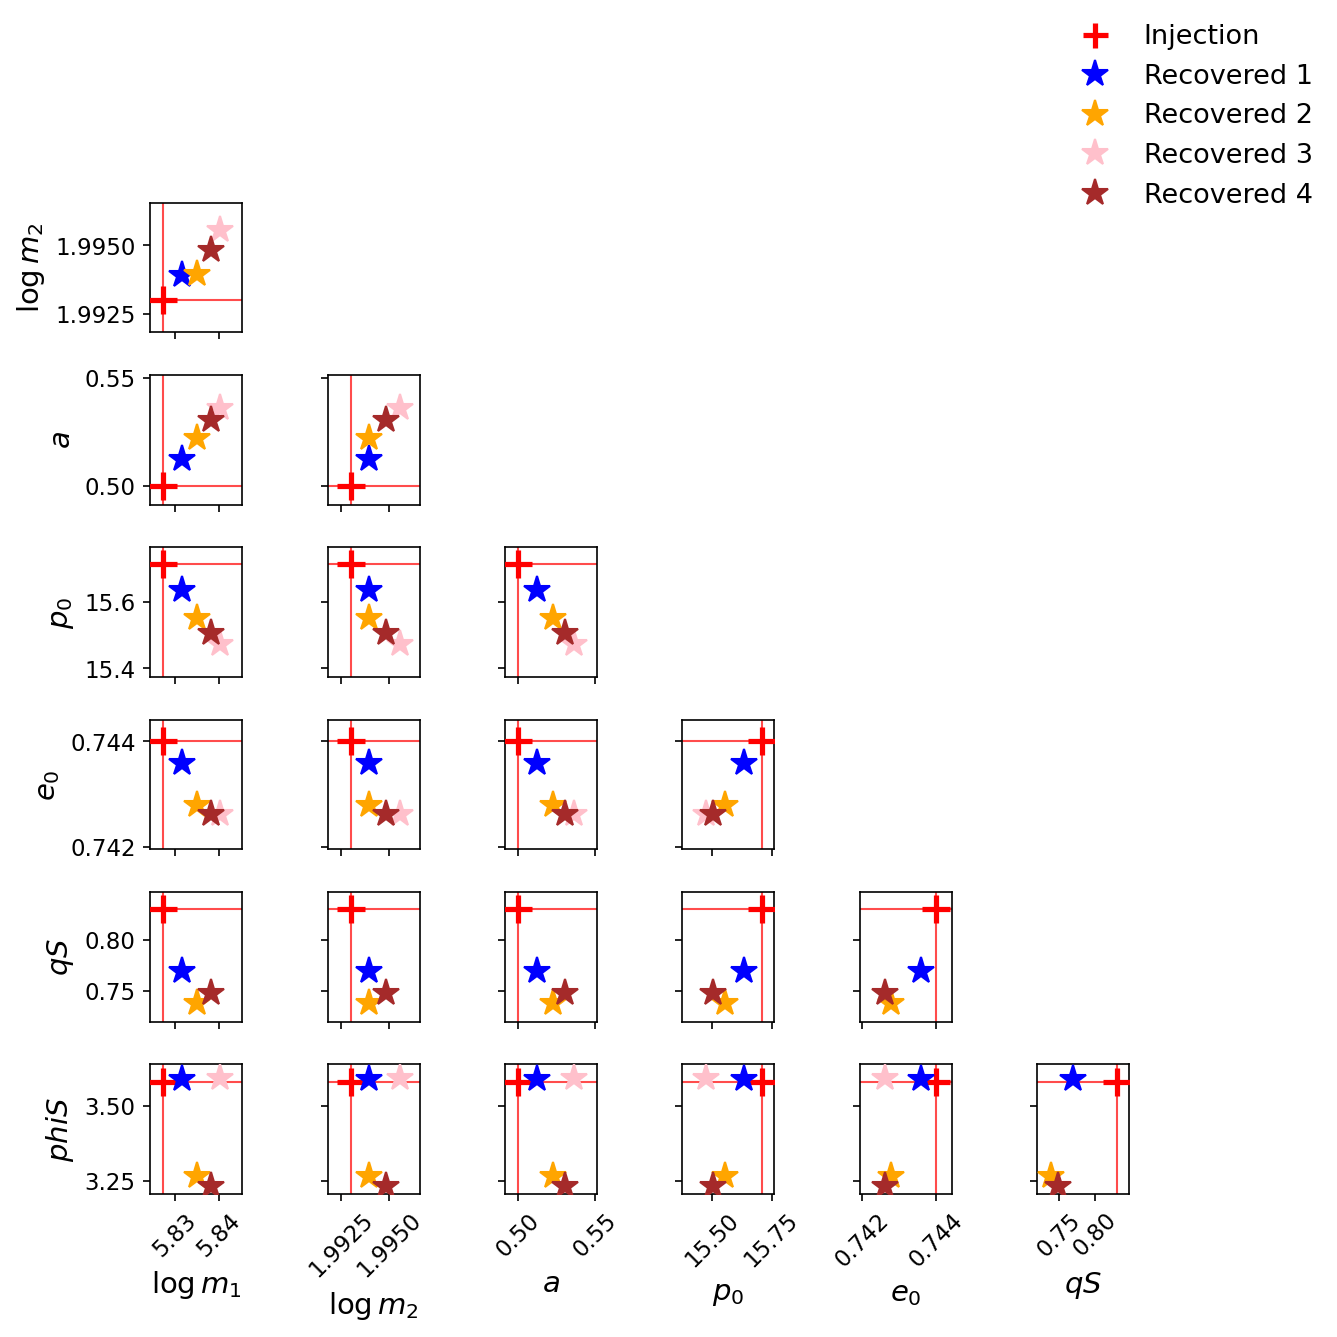

In [19]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()
maxld_pt2  = np.asarray(maxld_pt2).ravel()
maxld_pt3  = np.asarray(maxld_pt3).ravel()
maxld_pt4  = np.asarray(maxld_pt4).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)
        # recovered MAP point
        ax.plot(maxld_pt2[j], maxld_pt2[i], '*', color='orange',
                ms=13, zorder=4)
        # recovered MAP point
        ax.plot(maxld_pt3[j], maxld_pt3[i], '*', color='pink',
                ms=13, zorder=4)

        ax.plot(maxld_pt4[j], maxld_pt4[i], '*', color='brown',
                ms=13, zorder=4)
        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
    Line2D([0], [0], color='orange', marker='*', ls='', ms=13,          label='Recovered 2'),
    Line2D([0], [0], color='pink', marker='*', ls='', ms=13,          label='Recovered 3'),
    Line2D([0], [0], color='brown', marker='*', ls='', ms=13,          label='Recovered 4'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [ ]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.82717561,  1.99291651,  0.49948267, 15.71493656,  0.74403081,
         0.83053685,  3.55278464]])

In [ ]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [21]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [22]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


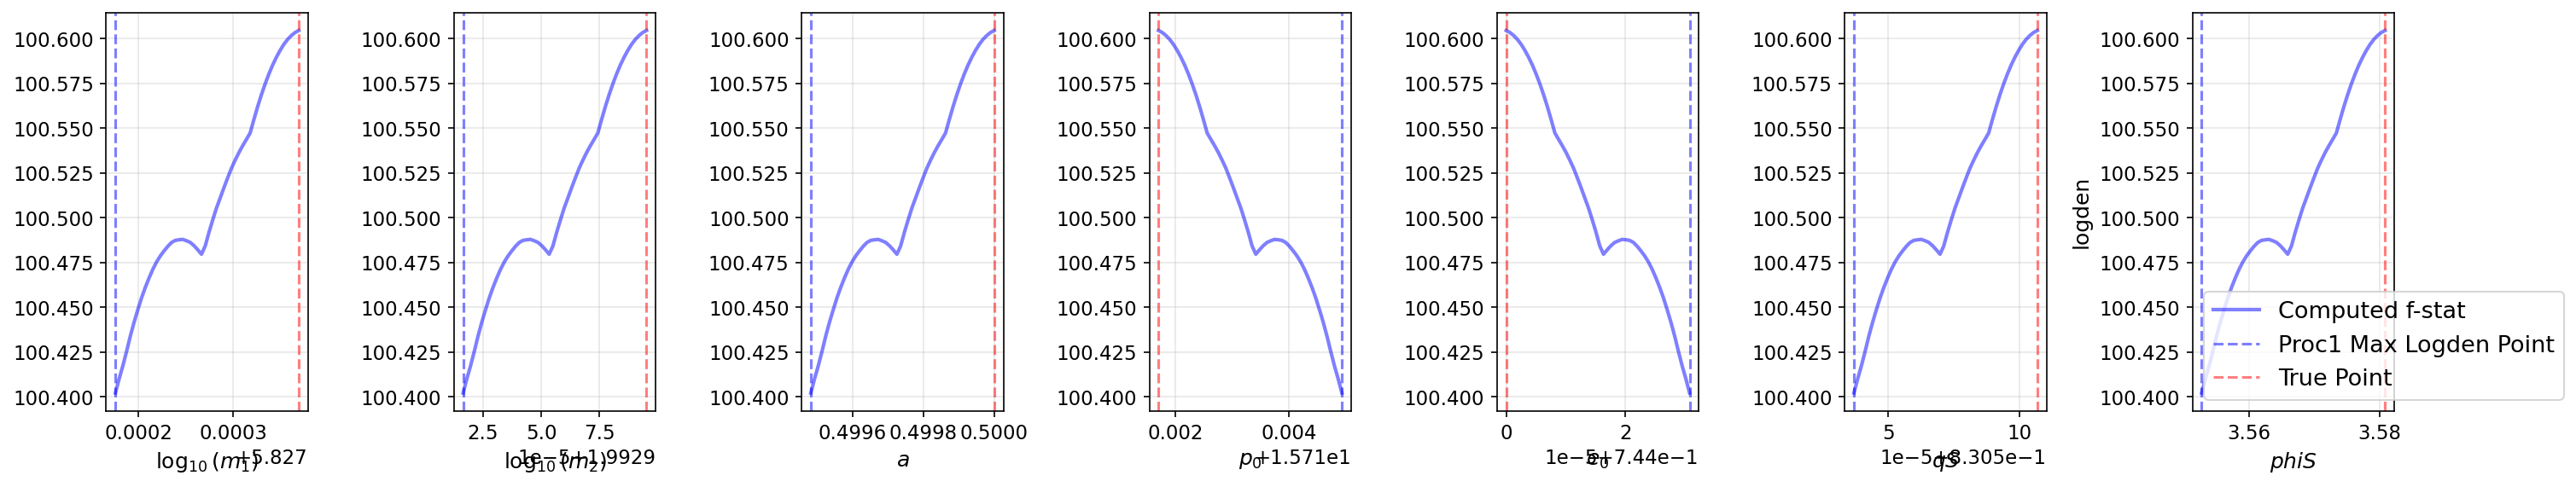

In [23]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
